## Polity coverage by century

This notebook shows how many individuals in the database have been
successfully assigned to a historical polity (via the Cliopatria matching),
broken down by century. The y-axis uses a log scale.

### 1. Query polity-assigned individuals per century

Count distinct `wikidata_id` in `individuals_cliopatria` grouped by century.
Only centuries with at least 5 individuals are kept.

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DB = '../data/humans_clean.sqlite3'

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-1000000')

query = """
    SELECT (impact_date / 100) * 100 AS century, COUNT(DISTINCT wikidata_id) AS cnt
    FROM individuals_cliopatria
    WHERE impact_date BETWEEN -3500 AND 2050
    GROUP BY century ORDER BY century
"""

df = pd.read_sql(query, conn)
conn.close()

df = df[(df['century'] >= -3500) & (df['century'] <= 2000) & (df['cnt'] >= 5)]
centuries = df['century'].tolist()
polity_counts = df['cnt'].tolist()

print(f'{len(centuries)} centuries, {sum(polity_counts):,} individuals assigned to a polity')
df

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
  File "/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_96482/1079960094.py", line 2, in <module>
    import pandas as pd
ModuleNotFoundError: No module named 'pandas'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.10/site-packages/pygments/styles/__init__.py", line 45, in get_style_by_name
ModuleNotFoundError: No module named 'pygments.styles.default'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2170, in showtraceback
  Fil

### 2. Figure

Bar chart with one bar per century. Log y-axis with plain number formatting.

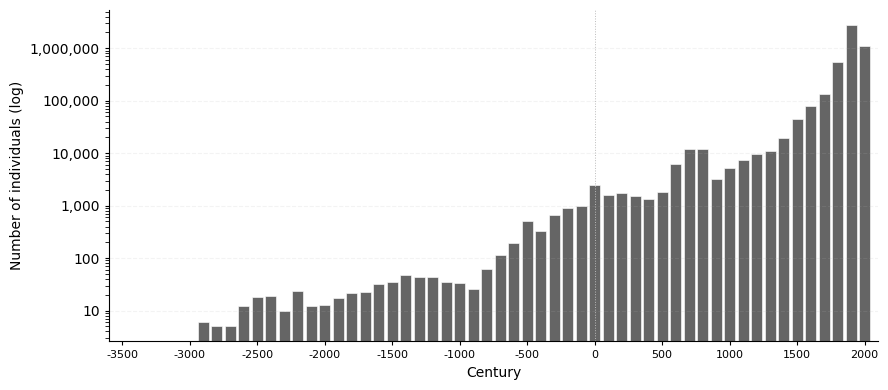

: 

: 

: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(centuries, polity_counts, width=80, color='#4a4a4a', edgecolor='white',
       linewidth=0.5, alpha=0.85)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Century')
ax.set_ylabel('Number of individuals (log)')
ax.set_xlim(-3600, 2100)

xticks = list(range(-3500, 2500, 500))
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3)
ax.grid(axis='y', alpha=0.15, linestyle='--')
ax.axvline(x=0, color='#bbbbbb', linestyle=':', linewidth=0.7)

plt.tight_layout()
plt.show()

### 3. Percentage of individuals with assigned polity per century

Compare total individuals (from `individuals_impact_date`) with those assigned to a polity.

In [ ]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-1000000')

# Total individuals per century
query_total = """
    SELECT (CAST(impact_date AS INTEGER) / 100) * 100 AS century, 
           COUNT(DISTINCT wikidata_id) AS total_cnt
    FROM individuals_impact_date
    WHERE CAST(impact_date AS INTEGER) BETWEEN -3500 AND 2050
    GROUP BY century ORDER BY century
"""

# Individuals with polity per century
query_polity = """
    SELECT (impact_date / 100) * 100 AS century, 
           COUNT(DISTINCT wikidata_id) AS polity_cnt
    FROM individuals_cliopatria
    WHERE impact_date BETWEEN -3500 AND 2050
    GROUP BY century ORDER BY century
"""

df_total = pd.read_sql(query_total, conn)
df_polity = pd.read_sql(query_polity, conn)
conn.close()

# Merge and calculate percentage
df_pct = df_total.merge(df_polity, on='century', how='left')
df_pct['polity_cnt'] = df_pct['polity_cnt'].fillna(0)
df_pct['pct_with_polity'] = (df_pct['polity_cnt'] / df_pct['total_cnt']) * 100

# Filter centuries
df_pct = df_pct[(df_pct['century'] >= -3500) & (df_pct['century'] <= 2000) & (df_pct['total_cnt'] >= 5)]

print(f"Overall coverage: {df_pct['polity_cnt'].sum():,.0f} / {df_pct['total_cnt'].sum():,.0f} = {df_pct['polity_cnt'].sum() / df_pct['total_cnt'].sum() * 100:.1f}%")
df_pct

: 

: 

: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(df_pct['century'], df_pct['pct_with_polity'], width=80, color='#2d6a4f', 
       edgecolor='white', linewidth=0.5, alpha=0.85)

ax.set_xlabel('Century')
ax.set_ylabel('% of individuals with assigned polity')
ax.set_xlim(-3600, 2100)
ax.set_ylim(0, 100)

xticks = list(range(-3500, 2500, 500))
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3)
ax.grid(axis='y', alpha=0.15, linestyle='--')
ax.axvline(x=0, color='#bbbbbb', linestyle=':', linewidth=0.7)

# Add horizontal line at overall average
overall_pct = df_pct['polity_cnt'].sum() / df_pct['total_cnt'].sum() * 100
ax.axhline(y=overall_pct, color='#d62828', linestyle='--', linewidth=1, alpha=0.7, 
           label=f'Overall: {overall_pct:.1f}%')
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

: 

: 

: 